# 30-Month Work-Disability Risk in SLE
### Adapted from the 180-day post-chemo mortality survival pipeline

This notebook replicates the modeling pipeline of the original 180-day survival
notebook (LSTM, GRU, Logistic Regression, Random Survival Forest, Cox PH, plus
permutation importance, calibration, decision-curve analysis, and a SHAP
dashboard) and retargets it at **systemic lupus erythematosus (SLE)**:

- **Outcome:** transition from `Employed` to `Disability Benefit` status
  (formal work disability), instead of 180-day mortality.
- **Horizon:** 30 months (≈913 days), instead of 180 days.
- **Data:** `sledatacutsdi.csv` (visit-level SLE registry extract with
  SLEDAI/SDI sub-scores and treatment fields), instead of the oncology
  `pcdata.csv`.
- **External validation is intentionally omitted**, per task instructions.

The landmarking and censoring logic below follows the "Step 1–3, as
implemented (v16)" specification supplied with this task: a growing-window
landmark set built from calendar-time visit gaps, with death (12-month) and
administrative-exit (6-month) censoring trims, and each landmark row
inverse-weighted by the number of landmarks contributed by its patient.

**Implementation note:** the sandbox this notebook was built in could not fit
both TensorFlow and PyTorch on disk, so the GRU/LSTM sequential models and all
denoising-autoencoder imputers use **PyTorch** rather than
TensorFlow/Keras — architecturally identical (2-layer recurrent
encoder-decoder, masked-MSE imputation loss; 2-layer recurrent classifier with
dropout + batch-norm and a time-distributed sigmoid head, trained on balanced
class minibatches) but a different framework.


## Shared utilities (metrics, calibration, plotting, DAE imputer)

In [1]:
"""Shared utilities: metrics, calibration, plots -- mirrors the reporting
helpers used across every model in the original notebook (Wilson CIs,
threshold search for 85% sensitivity, calibration slope/intercept, decision
curve analysis, risk-distribution + calibration plot, permutation
importance)."""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (recall_score, confusion_matrix, balanced_accuracy_score,
                              brier_score_loss, roc_curve, auc, precision_recall_curve,
                              average_precision_score)
from sklearn.calibration import calibration_curve
from lifelines.utils import concordance_index
from scipy import stats

sns.set_style("whitegrid")
OUT_DIR = "figs"


def wilson_ci(p, n, z=1.96):
    if n <= 0:
        return 0.0, 0.0
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    err = z * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2))) / denom
    return max(0, center - err), min(1, center + err)


def find_threshold_for_sensitivity(y_true, risks, target_sens=0.85):
    thresholds = np.linspace(0, 1, 100)
    best_t = 0.5
    for t in thresholds:
        if recall_score(y_true, (risks >= t).astype(int)) >= target_sens:
            best_t = t
        else:
            break
    return best_t


def calibration_stats(y_true, risks, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, risks, n_bins=n_bins)
    slope, intercept, r_value, p_value, std_err = stats.linregress(prob_pred, prob_true)
    return slope, intercept, r_value ** 2, prob_true, prob_pred


def report_comprehensive_metrics(model_name, y_true, y_pred, risks, c_idx, duration=None, event=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    slope, intercept, r2, _, _ = calibration_stats(y_true, risks)
    b_score = brier_score_loss(y_true, risks)

    metrics = {
        "Sensitivity": (tp / (tp + fn) if (tp + fn) > 0 else 0, tp + fn),
        "Specificity": (tn / (tn + fp) if (tn + fp) > 0 else 0, tn + fp),
        "PPV": (tp / (tp + fp) if (tp + fp) > 0 else 0, tp + fp),
        "NPV": (tn / (tn + fn) if (tn + fn) > 0 else 0, tn + fn),
        "Balanced Accuracy": (balanced_accuracy_score(y_true, y_pred), len(y_true)),
    }

    print("\n" + "=" * 78)
    print(f"{model_name} -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS")
    print("-" * 78)
    print(f"{'METRIC':<30} | {'VALUE':<10} | {'95% CI / INFO':<25}")
    print("-" * 78)
    print(f"{'Concordance Index':<30} | {c_idx:.4f}     | Discrimination")
    print(f"{'Brier Score':<30} | {b_score:.4f}     | Overall accuracy (lower=better)")
    print(f"{'Calibration Slope':<30} | {slope:.4f}     | Ideal = 1.0")
    print(f"{'Calibration Intercept':<30} | {intercept:.4f}     | Ideal = 0.0")
    for name, (val, n) in metrics.items():
        low, high = wilson_ci(val, n)
        print(f"{name:<30} | {val:.4f}     | [{low:.3f}, {high:.3f}]")
    print("=" * 78)
    return {"c_index": c_idx, "brier": b_score, "slope": slope, "intercept": intercept,
            **{k: v[0] for k, v in metrics.items()}}


def print_operational_metrics(model_name, metadata_df, y_pred_col="y_pred", label_col="label",
                               pid_col="pid", date_col="visit_date", pt=0.15):
    df = metadata_df.copy()
    n = len(df)
    alerts_per_100 = (df[y_pred_col].sum() / n) * 100
    prop_alert = df[y_pred_col].mean()

    tp_mask = (df[y_pred_col] == 1) & (df[label_col] == 1)
    tiw_tp, tiw_fp = [], []
    for pid, g in df.groupby(pid_col):
        alerts = g[g[y_pred_col] == 1]
        if not alerts.empty:
            duration = (g[date_col].max() - alerts[date_col].min()).days
            if g[label_col].any():
                tiw_tp.append(duration)
            else:
                tiw_fp.append(duration)

    tp = ((df[y_pred_col] == 1) & (df[label_col] == 1)).sum()
    fp = ((df[y_pred_col] == 1) & (df[label_col] == 0)).sum()
    net_benefit = (tp / n) - (fp / n) * (pt / (1 - pt))

    print("\n" + "=" * 70)
    print(f"{model_name} -- OPERATIONAL / CLINICAL-BURDEN METRICS")
    print("-" * 70)
    print(f"{'Alerts per 100 Patient-Visits':<35} | {alerts_per_100:.2f}")
    print(f"{'Proportion of Visits in Alert':<35} | {prop_alert:.2%}")
    print(f"{'Median Time-in-Warning (TP, days)':<35} | {np.median(tiw_tp) if tiw_tp else 0:.1f}")
    print(f"{'Median Time-in-Warning (FP, days)':<35} | {np.median(tiw_fp) if tiw_fp else 0:.1f}")
    print(f"{'Net Benefit (at pt=0.15)':<35} | {net_benefit:.4f}")
    print("=" * 70)


def plot_decision_curve(model_name, y_true, y_prob, color="#2c7da0", save=None):
    thresholds = np.linspace(0.01, 0.99, 100)
    n = len(y_true)
    net_benefit_model, net_benefit_all = [], []
    for t in thresholds:
        tp = np.sum((y_prob >= t) & (y_true == 1))
        fp = np.sum((y_prob >= t) & (y_true == 0))
        net_benefit_model.append((tp / n) - (fp / n) * (t / (1 - t)))
        tp_all, fp_all = np.sum(y_true == 1), np.sum(y_true == 0)
        net_benefit_all.append((tp_all / n) - (fp_all / n) * (t / (1 - t)))

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, net_benefit_model, label=f"{model_name}", color=color, lw=2)
    plt.plot(thresholds, net_benefit_all, label="Treat All", linestyle="--", color="gray", alpha=0.7)
    plt.axhline(0, label="Treat None", color="black", lw=1)
    plt.ylim(-0.05, max(0.05, max(net_benefit_model) * 1.2))
    plt.xlabel("Probability Threshold")
    plt.ylabel("Net Benefit")
    plt.title(f"Decision Curve Analysis -- {model_name}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_risk_distribution_and_calibration(model_name, risks, y_true, threshold, color_pos="#e74c3c",
                                            color_neg="#3498db", save=None):
    fig, ax1 = plt.subplots(figsize=(10, 6))
    sns.histplot(risks[y_true == 1], color=color_pos, label="Disability within 30mo", kde=True,
                 bins=30, alpha=0.5, ax=ax1)
    sns.histplot(risks[y_true == 0], color=color_neg, label="No disability > 30mo", kde=True,
                 bins=30, alpha=0.3, ax=ax1)
    ax1.axvline(threshold, color="black", linestyle="--", label=f"Threshold: {threshold:.2f}")
    ax1.set_xlabel(f"{model_name} Standardized 30-Month Risk Score")
    ax1.set_ylabel("Landmark Count")

    ax2 = ax1.twinx()
    prob_true, prob_pred = calibration_curve(y_true, risks, n_bins=10)
    ax2.plot(prob_pred, prob_true, "s-", color="green", label="Observed")
    ax2.plot([0, 1], [0, 1], "k:", alpha=0.3)
    ax2.set_ylabel("Actual 30-Month Disability Rate")

    plt.title(f"30-Month Work-Disability Risk: Distribution & Calibration -- {model_name}")
    ax1.legend(loc="upper left")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_performance_grid(model_name, y_true, y_prob, best_t, save=None):
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color="#444444", lw=2, label=f"AUC = {roc_auc:.2f}")
    axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", alpha=0.6)
    axes[0].set_title("(a) ROC curve")
    axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
    axes[0].legend(loc="lower right")

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    axes[1].plot(recall, precision, color="#6b2d5c", lw=2, label=f"PR-AUC = {pr_auc:.3f}")
    axes[1].axhline(y=np.mean(y_true), color="gray", linestyle="--", alpha=0.6,
                     label=f"Baseline ({np.mean(y_true):.2f})")
    axes[1].set_title("(b) Precision-Recall curve")
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].legend(loc="upper right")

    thresholds = np.linspace(0, 1, 100)
    sens, spec, ppv, npv = [], [], [], []
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        ppv.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
        npv.append(tn / (tn + fn) if (tn + fn) > 0 else 1)

    axes[2].plot(thresholds, sens, color="#2d6b6b", lw=2, label="Sensitivity")
    axes[2].plot(thresholds, spec, color="#8c564b", lw=2, label="Specificity")
    axes[2].axvline(best_t, color="#444444", linestyle="--", alpha=0.8, label=f"Thresh {best_t:.2f}")
    axes[2].set_title("(c) Sensitivity-specificity trade-off")
    axes[2].set_xlabel("Threshold"); axes[2].legend(loc="lower left")

    axes[3].plot(thresholds, ppv, color="#546e7a", lw=2, label="PPV")
    axes[3].plot(thresholds, npv, color="#7e57c2", lw=2, label="NPV")
    axes[3].axvline(best_t, color="#444444", linestyle="--", alpha=0.8, label="Thresh")
    axes[3].set_title("(d) PPV-NPV trade-off")
    axes[3].set_xlabel("Threshold"); axes[3].legend(loc="lower left")

    plt.suptitle(f"{model_name} -- Performance Grid (30-Month Work-Disability Risk)", y=1.03, fontsize=14)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_permutation_importance(model_name, importance_df, save=None, color="viridis"):
    plt.figure(figsize=(11, 7))
    importance_df = importance_df.sort_values("Mean", ascending=False)
    y_pos = np.arange(len(importance_df))
    plt.barh(y_pos, importance_df["Mean"], color="#bcbdca", edgecolor="#444444", height=0.7)
    for idx, row in enumerate(importance_df.itertuples()):
        if "SD" in importance_df.columns:
            plt.errorbar(row.Mean, idx, xerr=row.SD, fmt="none", ecolor="black", capsize=5,
                         elinewidth=1.5, zorder=3)
        plt.text(row.Mean + (row.SD if "SD" in importance_df.columns else 0) + 0.002, idx,
                 f"{row.Mean:.3f}", va="center", fontweight="bold", fontsize=10)
    plt.yticks(y_pos, importance_df["Feature"], fontsize=12)
    plt.gca().invert_yaxis()
    plt.xlabel("Decrease in Concordance Index (Importance)", fontweight="bold", fontsize=13)
    plt.title(f"Permutation Feature Importance -- {model_name}", fontweight="bold", fontsize=15)
    plt.grid(axis="x", linestyle="-", alpha=0.3)
    plt.axvline(0, color="black", lw=1)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

"""Denoising autoencoder for learned feature imputation (PyTorch), used by
the LogReg, RSF and CoxPH landmark models -- mirrors the DAE module in the
original notebook's cells."""
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


class DAE(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 16), nn.ReLU(), nn.Linear(16, 8), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(8, 16), nn.ReLU(), nn.Linear(16, input_dim))

    def forward(self, x):
        return self.decoder(self.encoder(x))


def train_dae(X_nan, epochs=60, batch_size=32, seed=240):
    torch.manual_seed(seed)
    X_init = np.nan_to_num(X_nan, nan=np.nanmean(X_nan, axis=0))
    X_tensor = torch.FloatTensor(X_init)
    loader = DataLoader(TensorDataset(X_tensor, X_tensor), batch_size=batch_size, shuffle=True)

    dae = DAE(X_nan.shape[1])
    optimizer = optim.Adam(dae.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    dae.train()
    for _ in range(epochs):
        for data, target in loader:
            mask = torch.rand(data.shape) > 0.2
            noisy = data * mask
            optimizer.zero_grad()
            out = dae(noisy)
            loss = criterion(out, target)
            loss.backward()
            optimizer.step()
    return dae


def impute_with_dae(dae, X_nan):
    dae.eval()
    mask = np.isnan(X_nan)
    X_filled = np.nan_to_num(X_nan, nan=np.nanmean(X_nan, axis=0))
    X_tensor = torch.FloatTensor(X_filled)
    with torch.no_grad():
        reconstructed = dae(X_tensor).numpy()
    X_final = X_nan.copy()
    X_final[mask] = reconstructed[mask]
    return X_final

## Step 1–3 — Data, Landmark Set, and Censoring

Builds the growing-window landmark dataset directly from `sledatacutsdi.csv`:
eligibility requires `cat == 'Employed'` at every visit up to and including
the landmark; a patient's very last observed visit is dropped (no forward
information); death (`STATUS == 'Dead'`) trims the last 12 months of
follow-up before deriving the censoring clock, and administrative exit
(`end_state` in `{Unemployed, Early Retirement, Economically Inactive}`)
trims the last 6 months, anchored to the patient's last observed visit date.
Loss-to-follow-up is not separately identified and falls back to ordinary
right-censoring.


In [2]:
"""
Landmark data preparation for the 30-month work-disability model.

Implements Steps 1-3 of the modeling spec, adapted to sledatacutsdi.csv:
  - Step 1: raw visit-level record, calendar-time gaps kept as a feature.
  - Step 2: growing-window landmark set (every visit at which the patient is
    still Employed and has not yet been Employed at every prior visit only
    is eligible; the patient's last observed visit is dropped since it
    carries no forward information).
  - Step 3: censoring trims. Death -> drop the last 12 months of follow-up
    before deriving the censoring clock. Administrative exit (end_state in
    {Unemployed, Early Retirement, Economically Inactive}) -> drop the last
    6 months, anchored to the patient's last observed visit date (not the
    exact visit of exit, since end_state is a patient-level summary field
    here). LTFU is not separately identified: any censored landmark that is
    neither a detected death nor a detected administrative exit is treated
    as ordinary right-censoring.

Each landmark row is weighted by 1 / (number of landmark rows for that
patient), to counteract within-patient correlation, per the "as implemented
(v16)" note.
"""
import numpy as np
import pandas as pd

RAW_PATH = "sledatacutsdi.csv"

FEATURE_COLS = [
    "SLEDAI2_I",             # disease activity (SLEDAI-2K total)
    "score_n",               # cumulative organ damage (SDI)
    "age_at_record",         # age at visit
    "disease_duration_yrs",  # recomputed disease duration (ASSDT - DATEOFDX)
    "days_since_last_visit", # calendar gap since prior visit
    "cum_steroid_dose",      # cumulative treatment burden (steroids)
    "high_dose",             # currently on high-dose steroids (binary)
    "has_short_sick_leave",  # sick-leave history (binary)
]

DISPLAY_NAMES = {
    "SLEDAI2_I": "SLEDAI-2K (Disease Activity)",
    "score_n": "SDI Damage Score",
    "age_at_record": "Age",
    "disease_duration_yrs": "Disease Duration (yrs)",
    "days_since_last_visit": "Days Since Last Visit",
    "cum_steroid_dose": "Cumulative Steroid Dose",
    "high_dose": "Currently High-Dose Steroids",
    "has_short_sick_leave": "Prior Short Sick-Leave Spell",
}

ADMIN_EXIT_STATES = {"Unemployed", "Early Retirement", "Economically Inactive"}
DEATH_TRIM_DAYS = 365          # 12 months
ADMIN_TRIM_DAYS = 183          # 6 months
HORIZON_DAYS = round(30 * 365.25 / 12)  # 30-month horizon ~= 913 days


def _load_raw(path=RAW_PATH):
    df = pd.read_csv(path, low_memory=False)
    # De-duplicate visit rows: the extract contains occasional repeated
    # (PTNO, ASSDT) rows (e.g. a days_since_last_visit=0 artifact row
    # immediately following the real one). Keep the first occurrence.
    df = df.sort_index()
    df = df.drop_duplicates(subset=["PTNO", "ASSDT"], keep="first").reset_index(drop=True)

    df["ASSDT"] = pd.to_datetime(df["ASSDT"], errors="coerce")
    df["DATEOFDX"] = pd.to_datetime(df["DATEOFDX"], errors="coerce")
    df["DEATHDT"] = pd.to_datetime(df["DEATHDT"], errors="coerce")
    df["LCDT"] = pd.to_datetime(df["LCDT"], errors="coerce", utc=True).dt.tz_localize(None)

    df = df.dropna(subset=["PTNO", "ASSDT", "cat"]).copy()
    df["disease_duration_yrs"] = (df["ASSDT"] - df["DATEOFDX"]).dt.days / 365.25
    return df


def build_landmark_dataset(path=RAW_PATH, horizon_days=HORIZON_DAYS, verbose=True,
                            with_sequences=False, sequence_length=12):
    df = _load_raw(path)
    rows = []
    sequences = []
    n_patients = 0
    n_eligible_total = 0

    for pid, p_data in df.groupby("PTNO"):
        p_data = p_data.sort_values("ASSDT").reset_index(drop=True)
        n_patients += 1

        status = p_data["STATUS"].iloc[0]
        end_state = p_data["end_state"].iloc[0]
        last_fup = p_data["ASSDT"].max()

        if status == "Dead":
            trim_days = DEATH_TRIM_DAYS
        elif end_state in ADMIN_EXIT_STATES:
            trim_days = ADMIN_TRIM_DAYS
        else:
            trim_days = 0
        last_fup_trimmed = last_fup - pd.Timedelta(days=trim_days)

        # First transition to Disability Benefit, if any.
        db_mask = p_data["cat"] == "Disability Benefit"
        transition_date = p_data.loc[db_mask, "ASSDT"].min() if db_mask.any() else pd.NaT
        has_event = pd.notna(transition_date)

        # Growing-window eligibility: every visit up to and including j must
        # be 'Employed'. Eligibility ends at the first non-Employed visit.
        is_employed = (p_data["cat"] == "Employed").values
        if is_employed.all():
            n_eligible_prefix = len(p_data)
        else:
            n_eligible_prefix = np.argmax(~is_employed)  # index of first False

        # Drop the patient's last observed visit row (no forward info).
        last_row_idx = len(p_data) - 1
        eligible_idx = [i for i in range(n_eligible_prefix) if i != last_row_idx]

        patient_rows = []
        for i in eligible_idx:
            visit_date = p_data["ASSDT"].iloc[i]
            time_to_event = (transition_date - visit_date).days if has_event else None

            if has_event and 0 <= time_to_event <= horizon_days:
                label = 1
            elif has_event and time_to_event > horizon_days:
                label = 0
            elif (not has_event) and (last_fup_trimmed - visit_date).days >= horizon_days:
                label = 0
            else:
                continue

            duration = time_to_event if has_event else (last_fup_trimmed - visit_date).days
            duration = max(0.1, duration)

            feat = {c: p_data[c].iloc[i] for c in FEATURE_COLS}

            if with_sequences:
                seq = p_data[FEATURE_COLS].iloc[: i + 1].values.astype(float)[-sequence_length:]
                if len(seq) < sequence_length:
                    pad = sequence_length - len(seq)
                    seq = np.pad(seq, ((pad, 0), (0, 0)), mode="constant", constant_values=np.nan)
                sequences.append(seq)

            patient_rows.append({
                "pid": pid,
                "visit_date": visit_date,
                "label": label,
                "duration": duration,
                "event": 1 if has_event else 0,
                "status": status,
                "end_state": end_state,
                "censor_reason": ("death" if status == "Dead"
                                  else "admin_exit" if end_state in ADMIN_EXIT_STATES
                                  else "admin_or_ltfu"),
                **feat,
            })

        if patient_rows:
            n_w = len(patient_rows)
            for r in patient_rows:
                r["weight"] = 1.0 / n_w
            rows.extend(patient_rows)
            n_eligible_total += n_w

    land = pd.DataFrame(rows)

    if verbose:
        print("=" * 65)
        print("LANDMARK DATASET SUMMARY")
        print("-" * 65)
        print(f"Patients in extract:              {n_patients}")
        print(f"Patients contributing landmarks:   {land['pid'].nunique()}")
        print(f"Total landmark rows:                {len(land)}")
        print(f"Positive labels (30mo disability):  {int(land['label'].sum())} "
              f"({land['label'].mean():.2%})")
        print(f"Horizon (days / months):            {horizon_days} / 30")
        print(land["censor_reason"].value_counts())
        print("=" * 65)

    if with_sequences:
        X_seq = np.array(sequences)
        return land, X_seq
    return land

land, X_seq = build_landmark_dataset(with_sequences=True)

LANDMARK DATASET SUMMARY
-----------------------------------------------------------------
Patients in extract:              1025
Patients contributing landmarks:   429
Total landmark rows:                3964
Positive labels (30mo disability):  670 (16.90%)
Horizon (days / months):            913 / 30
censor_reason
admin_or_ltfu    2302
admin_exit       1182
death             480
Name: count, dtype: int64


## Model 1/5 — Logistic Regression (DAE-imputed features)

Training Denoising Autoencoder for imputation...

LogReg (DAE-imputed) -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.6087     | Discrimination
Brier Score                    | 0.2762     | Overall accuracy (lower=better)
Calibration Slope              | 0.2809     | Ideal = 1.0
Calibration Intercept          | 0.0259     | Ideal = 0.0
Sensitivity                    | 0.8522     | [0.823, 0.877]
Specificity                    | 0.3473     | [0.331, 0.364]
PPV                            | 0.2098     | [0.195, 0.226]
NPV                            | 0.9204     | [0.904, 0.934]
Balanced Accuracy              | 0.5998     | [0.584, 0.615]

LogReg -- OPERATIONAL / CLINICAL-BURDEN METRICS
----------------------------------

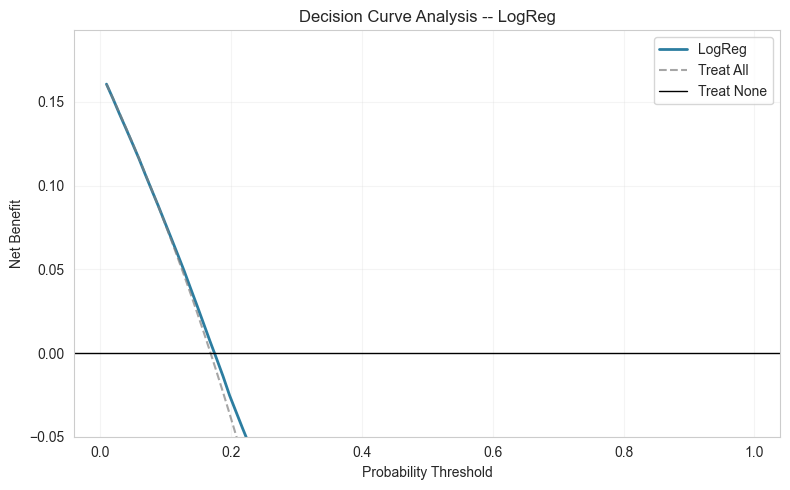

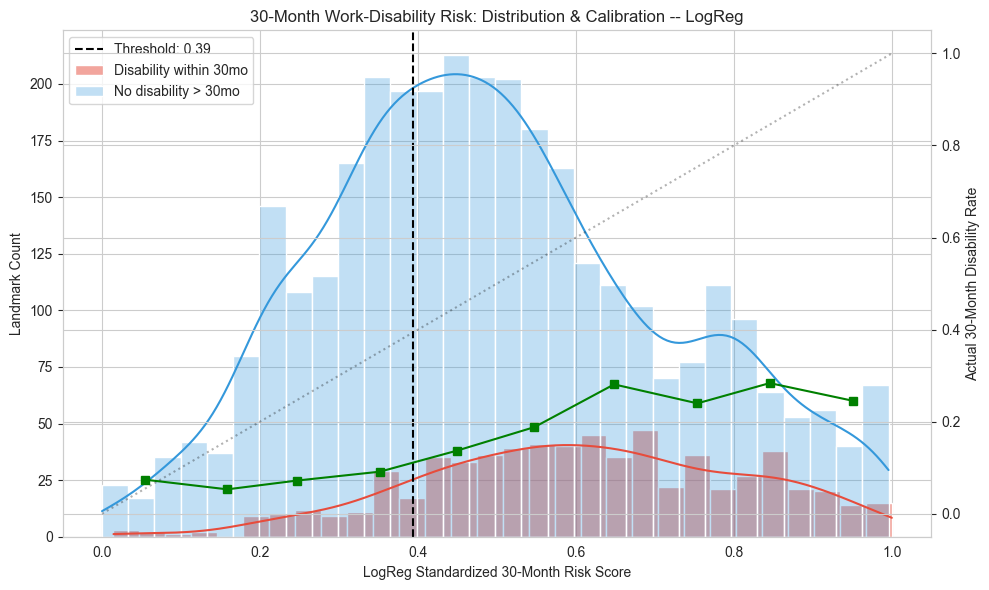

In [3]:
"""Landmark Logistic Regression, 30-month work-disability risk (SLE),
DAE-imputed features. Adapted from the notebook's LandmarkSurvivalLogReg."""
import numpy as np
import pandas as pd
import random
import torch
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from lifelines.utils import concordance_index


random.seed(240); np.random.seed(240); torch.manual_seed(240)


class LandmarkSurvivalLogReg:
    def __init__(self, horizon_days=913):
        self.horizon_days = horizon_days
        self.feature_cols = FEATURE_COLS
        self.scaler = StandardScaler()
        self.final_scaler = MinMaxScaler(feature_range=(0, 1))
        self.model = LogisticRegression(class_weight="balanced", random_state=240, max_iter=1000)
        self.dae = None

    def prepare_data(self, land):
        raw = land[self.feature_cols].values.astype(float)
        print("Training Denoising Autoencoder for imputation...")
        self.dae = train_dae(raw, epochs=50)
        imputed = impute_with_dae(self.dae, raw)
        scaled = self.scaler.fit_transform(imputed)
        X = scaled
        y = land["label"].values
        w = land["weight"].values
        return X, y, w

    def run_analysis(self, land):
        X, y, w = self.prepare_data(land)
        self.model.fit(X, y, sample_weight=w)

        risks_raw = self.model.predict_proba(X)[:, 1]
        risks = self.final_scaler.fit_transform(risks_raw.reshape(-1, 1)).flatten()
        risks = np.clip(risks, 1e-5, 1 - 1e-5)

        best_t = find_threshold_for_sensitivity(y, risks)
        y_pred = (risks >= best_t).astype(int)

        c_idx = concordance_index(land["duration"], -risks, land["event"])

        report_comprehensive_metrics("LogReg (DAE-imputed)", y, y_pred, risks, c_idx)
        meta = land.copy()
        meta["y_pred"] = y_pred
        print_operational_metrics("LogReg", meta, label_col="label")
        plot_decision_curve("LogReg", y, risks, color="#2c7da0")
        plot_risk_distribution_and_calibration("LogReg", risks, y, best_t)

        return {"model": self, "risks": risks, "y": y, "y_pred": y_pred, "c_index": c_idx,
                "best_t": best_t}

logreg_pipeline = LandmarkSurvivalLogReg(horizon_days=HORIZON_DAYS)
res_logreg = logreg_pipeline.run_analysis(land)

## Model 2/5 — Random Survival Forest (DAE-imputed features)

Training Denoising Autoencoder for feature imputation...

RSF (DAE-imputed) -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.7484     | Discrimination
Brier Score                    | 0.1416     | Overall accuracy (lower=better)
Calibration Slope              | 0.7466     | Ideal = 1.0
Calibration Intercept          | -0.0624     | Ideal = 0.0
Sensitivity                    | 0.8507     | [0.822, 0.876]
Specificity                    | 0.5641     | [0.547, 0.581]
PPV                            | 0.2841     | [0.265, 0.304]
NPV                            | 0.9489     | [0.938, 0.958]
Balanced Accuracy              | 0.7074     | [0.693, 0.721]

RSF -- OPERATIONAL / CLINICAL-BURDEN METRICS
-------------------------------

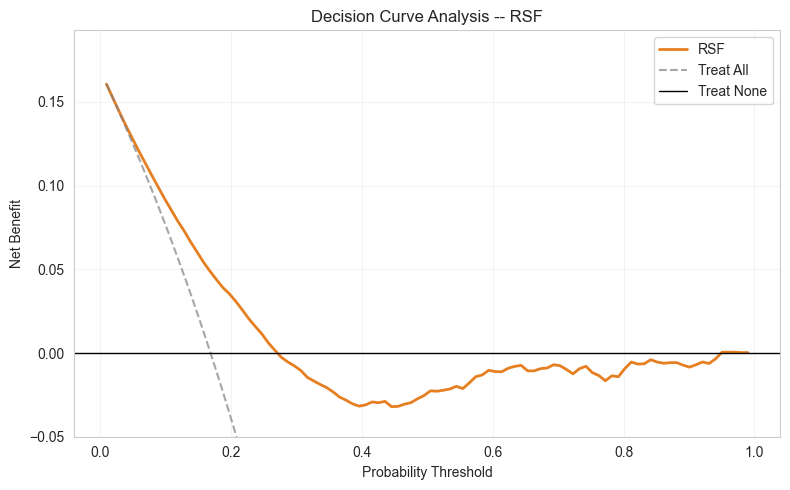

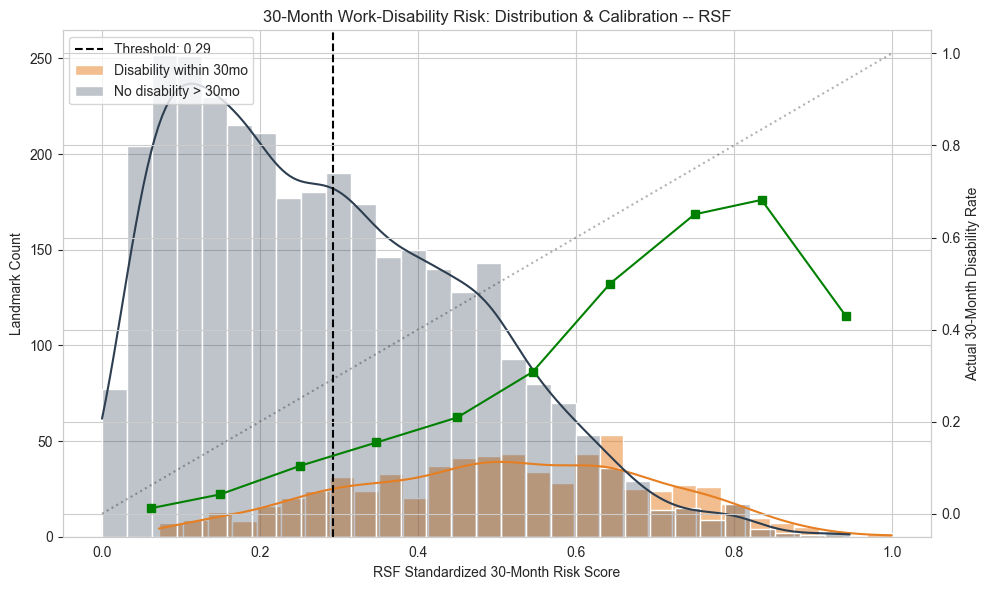

In [4]:
"""Landmark Random Survival Forest, 30-month work-disability risk (SLE),
DAE-imputed features. Adapted from the notebook's LandmarkSurvivalRSF."""
import numpy as np
import pandas as pd
import random
import torch
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sksurv.ensemble import RandomSurvivalForest
from lifelines.utils import concordance_index


random.seed(240); np.random.seed(240); torch.manual_seed(240)


class LandmarkSurvivalRSF:
    def __init__(self, horizon_days=913):
        self.horizon_days = horizon_days
        self.feature_cols = FEATURE_COLS
        self.scaler = StandardScaler()
        self.final_scaler = MinMaxScaler(feature_range=(0, 1))
        self.model = RandomSurvivalForest(
            n_estimators=100, min_samples_split=10, min_samples_leaf=15,
            max_features="sqrt", n_jobs=-1, random_state=240,
        )
        self.dae = None

    def prepare_data(self, land):
        raw = land[self.feature_cols].values.astype(float)
        print("Training Denoising Autoencoder for feature imputation...")
        self.dae = train_dae(raw, epochs=60)
        imputed = impute_with_dae(self.dae, raw)
        scaled = self.scaler.fit_transform(imputed)

        y_struct = np.array(
            list(zip(land["event"].astype(bool), land["duration"].astype(float))),
            dtype=[("event", "bool"), ("time", "float")],
        )
        return scaled, land["label"].values, y_struct, land["weight"].values

    def run_analysis(self, land):
        X, y, y_surv, w = self.prepare_data(land)
        # sksurv's RandomSurvivalForest.fit does not accept sample_weight
        # directly on all versions; fall back gracefully if unsupported.
        try:
            self.model.fit(X, y_surv, sample_weight=w)
        except TypeError:
            self.model.fit(X, y_surv)

        risks_raw = self.model.predict(X)
        risks = self.final_scaler.fit_transform(risks_raw.reshape(-1, 1)).flatten()
        risks = np.clip(risks, 1e-5, 1 - 1e-5)

        best_t = find_threshold_for_sensitivity(y, risks)
        y_pred = (risks >= best_t).astype(int)

        c_idx = concordance_index(land["duration"], -risks, land["event"])

        report_comprehensive_metrics("RSF (DAE-imputed)", y, y_pred, risks, c_idx)
        meta = land.copy()
        meta["y_pred"] = y_pred
        print_operational_metrics("RSF", meta, label_col="label")
        plot_decision_curve("RSF", y, risks, color="#e67e22")
        plot_risk_distribution_and_calibration("RSF", risks, y, best_t,
                                                color_pos="#e67e22", color_neg="#2c3e50")

        return {"model": self, "risks": risks, "y": y, "y_pred": y_pred, "c_index": c_idx,
                "best_t": best_t}

rsf_pipeline = LandmarkSurvivalRSF(horizon_days=HORIZON_DAYS)
res_rsf = rsf_pipeline.run_analysis(land)

## Model 3/5 — Cox Proportional Hazards (DAE-imputed, balanced fit)

Training Denoising Autoencoder for feature imputation...

CoxPH (DAE-imputed, balanced fit) -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.6047     | Discrimination
Brier Score                    | 0.3089     | Overall accuracy (lower=better)
Calibration Slope              | 0.6812     | Ideal = 1.0
Calibration Intercept          | -0.1366     | Ideal = 0.0
Sensitivity                    | 0.8672     | [0.839, 0.891]
Specificity                    | 0.3373     | [0.321, 0.354]
PPV                            | 0.2102     | [0.195, 0.226]
NPV                            | 0.9258     | [0.910, 0.939]
Balanced Accuracy              | 0.6022     | [0.587, 0.617]

CoxPH -- OPERATIONAL / CLINICAL-BURDEN METRICS
-------------

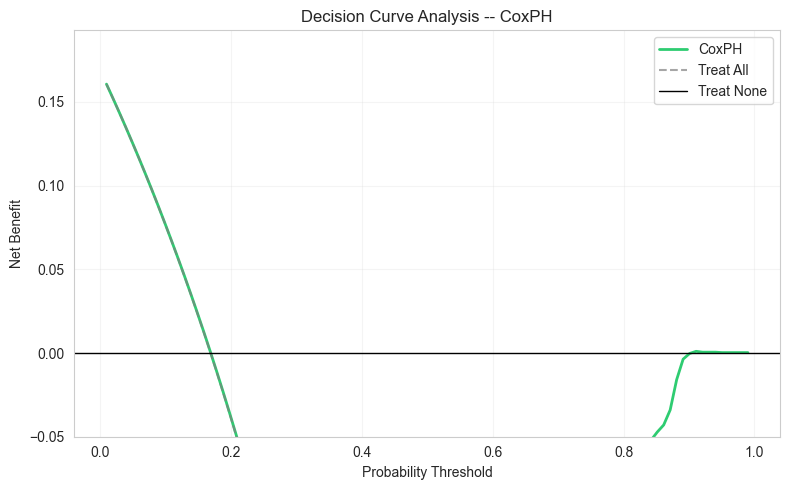

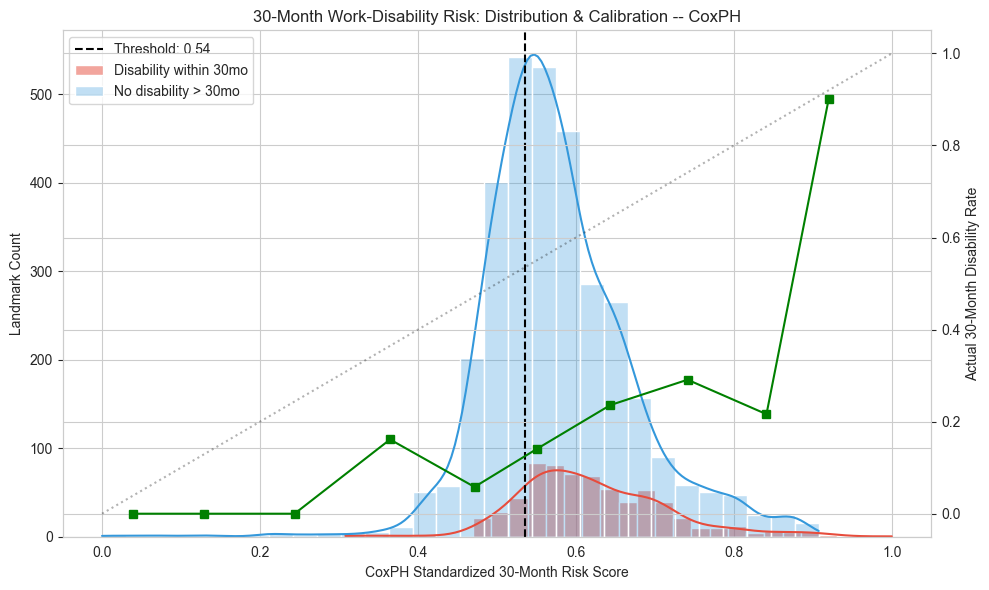


Cox model coefficients (hazard ratios):
                           coef  exp(coef)             p
covariate                                               
SLEDAI2_I              0.085524   1.089287  1.131426e-15
score_n                0.120528   1.128092  2.694425e-50
age_at_record          0.025408   1.025733  1.619344e-02
disease_duration_yrs  -0.044106   0.956853  1.044272e-06
days_since_last_visit -0.114731   0.891606  2.758791e-48
cum_steroid_dose       0.074377   1.077213  7.772716e-55
high_dose              0.023163   1.023433  2.661611e-02
has_short_sick_leave   0.044320   1.045317  5.024666e-07


In [5]:
"""Landmark Cox Proportional Hazards model, 30-month work-disability risk
(SLE), DAE-imputed features, balanced (oversampled) fit. Adapted from the
notebook's LandmarkSurvivalCoxPH."""
import numpy as np
import pandas as pd
import random
import torch
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index


random.seed(240); np.random.seed(240); torch.manual_seed(240)


class LandmarkSurvivalCoxPH:
    def __init__(self, horizon_days=913):
        self.horizon_days = horizon_days
        self.feature_cols = FEATURE_COLS
        self.scaler = StandardScaler()
        self.final_scaler = MinMaxScaler(feature_range=(0, 1))
        self.model = CoxPHFitter(penalizer=0.1)
        self.dae = None

    def prepare_data(self, land):
        raw = land[self.feature_cols].values.astype(float)
        print("Training Denoising Autoencoder for feature imputation...")
        self.dae = train_dae(raw, epochs=100)
        imputed = impute_with_dae(self.dae, raw)
        scaled = self.scaler.fit_transform(imputed)

        data = land.copy().reset_index(drop=True)
        data[self.feature_cols] = scaled
        return data

    def run_analysis(self, land):
        data = self.prepare_data(land)

        pos_df = data[data["label"] == 1]
        neg_df = data[data["label"] == 0]
        pos_over = pos_df.sample(n=len(neg_df), replace=True, random_state=240)
        balanced = pd.concat([neg_df, pos_over]).sample(frac=1, random_state=240)

        train_cols = self.feature_cols + ["duration", "event", "weight"]
        self.model.fit(balanced[train_cols], duration_col="duration", event_col="event",
                        weights_col="weight", robust=True)

        surv = self.model.predict_survival_function(data[self.feature_cols],
                                                      times=[self.horizon_days]).T
        risks_raw = 1 - surv.values.flatten()
        risks = self.final_scaler.fit_transform(risks_raw.reshape(-1, 1)).flatten()
        risks = np.clip(risks, 1e-5, 1 - 1e-5)
        y = data["label"].values

        best_t = find_threshold_for_sensitivity(y, risks)
        y_pred = (risks >= best_t).astype(int)
        c_idx = concordance_index(data["duration"], -risks, data["event"])

        report_comprehensive_metrics("CoxPH (DAE-imputed, balanced fit)", y, y_pred, risks, c_idx)
        meta = data.copy()
        meta["y_pred"] = y_pred
        print_operational_metrics("CoxPH", meta, label_col="label")
        plot_decision_curve("CoxPH", y, risks, color="#2ecc71")
        plot_risk_distribution_and_calibration("CoxPH", risks, y, best_t)

        print("\nCox model coefficients (hazard ratios):")
        print(self.model.summary[["coef", "exp(coef)", "p"]])

        return {"model": self, "risks": risks, "y": y, "y_pred": y_pred, "c_index": c_idx,
                "best_t": best_t}

cox_pipeline = LandmarkSurvivalCoxPH(horizon_days=HORIZON_DAYS)
res_cox = cox_pipeline.run_analysis(land)

## Model 4/5 — Sequential GRU

Temporal (GRU) autoencoder imputation over the last 12 visits, followed by a
2-layer GRU classifier trained on class-balanced minibatches. Reports the
same comprehensive metrics as the tabular models plus the full performance
grid (ROC / PR / sensitivity-specificity / PPV-NPV) and permutation feature
importance (C-index drop).


Training Temporal GRU Autoencoder for Imputation...
Training Survival GRU...

GRU (Sequential) -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.8117     | Discrimination
Brier Score                    | 0.1281     | Overall accuracy (lower=better)
Calibration Slope              | 0.7731     | Ideal = 1.0
Calibration Intercept          | -0.1321     | Ideal = 0.0
Sensitivity                    | 0.8597     | [0.831, 0.884]
Specificity                    | 0.7975     | [0.783, 0.811]
PPV                            | 0.4634     | [0.436, 0.491]
NPV                            | 0.9655     | [0.958, 0.972]
Balanced Accuracy              | 0.8286     | [0.817, 0.840]

GRU (Sequential) -- OPERATIONAL / CLINICAL-BURDEN METRICS

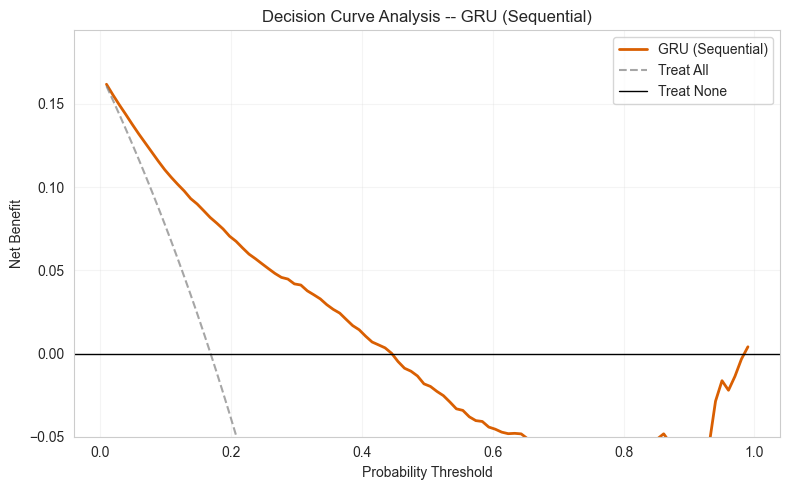

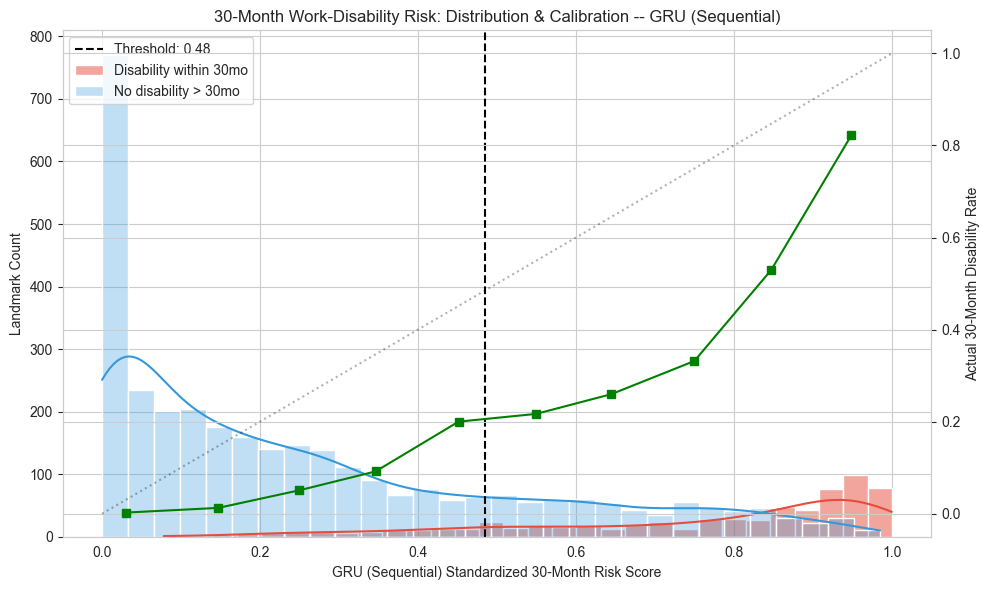

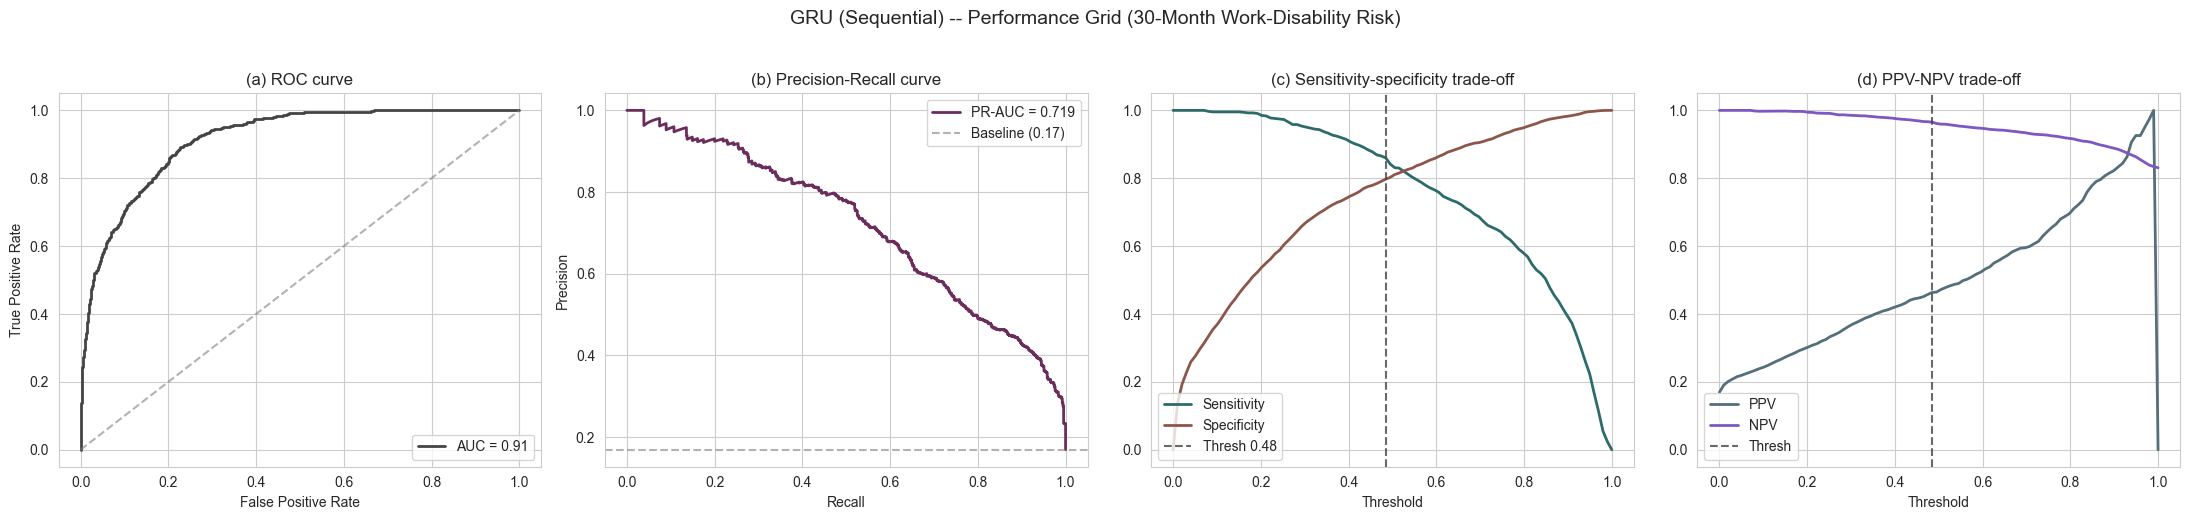

Calculating Permutation Feature Importance...


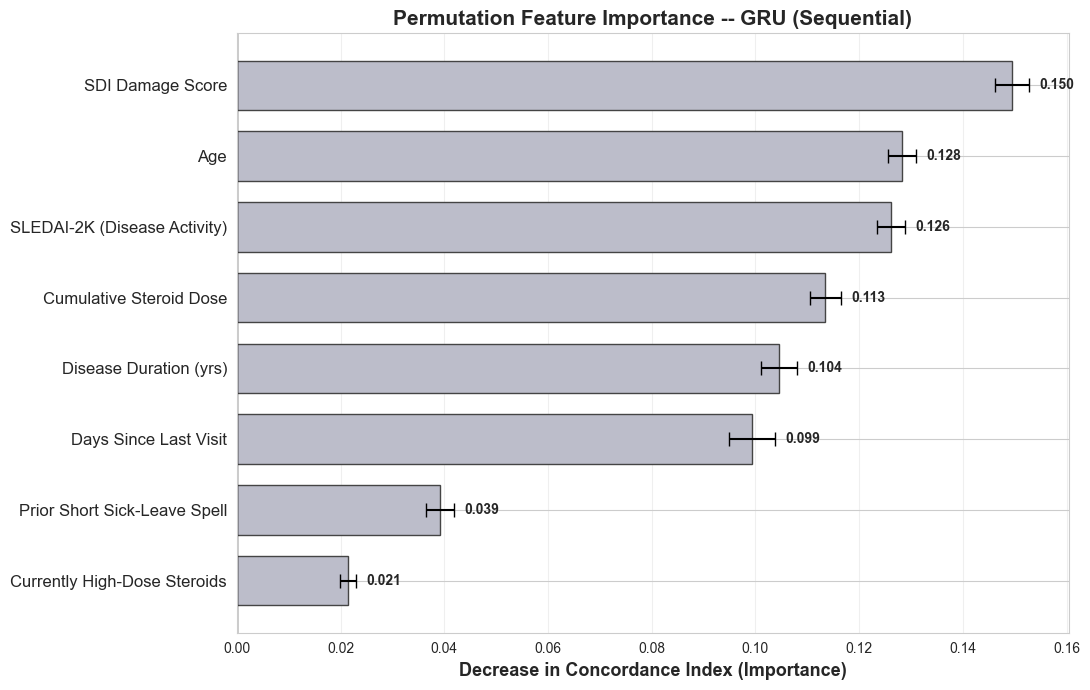

In [6]:
"""Sequential (GRU / LSTM) landmark model for 30-month work-disability risk.

Architecture mirrors the notebook's SequentialSurvivalGRU / -LSTM classes:
  1. a temporal autoencoder (same recurrent cell type) trained with a
     masked-MSE loss to reconstruct/impute the padded, possibly-missing
     visit sequences;
  2. a 2-layer recurrent classifier (dropout + batch-norm) with a
     time-distributed sigmoid head, trained with balanced (1:1 class)
     minibatches;
  3. the same reporting suite as the other models (comprehensive metrics,
     operational/clinical-burden metrics, decision curve, risk distribution
     + calibration, performance grid, permutation importance).

Implemented in PyTorch (the sandbox has no disk budget for a second deep
learning framework alongside PyTorch, so both the GRU and LSTM variants of
the original TensorFlow code are reproduced here with torch.nn.GRU /
torch.nn.LSTM, which are architecturally identical RNN cells).
"""
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from lifelines.utils import concordance_index



def masked_mse(y_true, y_pred, mask):
    diff2 = (y_true - y_pred) ** 2 * mask
    return diff2.sum() / (mask.sum() + 1e-7)


class RecurrentAutoencoder(nn.Module):
    def __init__(self, input_dim, cell="gru"):
        super().__init__()
        rnn = nn.GRU if cell == "gru" else nn.LSTM
        self.enc1 = rnn(input_dim, 64, batch_first=True)
        self.enc2 = rnn(64, 32, batch_first=True)
        self.dec1 = rnn(32, 32, batch_first=True)
        self.dec2 = rnn(32, 64, batch_first=True)
        self.out = nn.Linear(64, input_dim)

    def forward(self, x):
        seq_len = x.shape[1]
        h, _ = self.enc1(x)
        _, hN = self.enc2(h)
        latent = hN[0] if isinstance(hN, tuple) else hN
        latent = latent[-1]  # (batch, 32)
        rep = latent.unsqueeze(1).repeat(1, seq_len, 1)
        h, _ = self.dec1(rep)
        h, _ = self.dec2(h)
        return self.out(h)


class RecurrentClassifier(nn.Module):
    def __init__(self, input_dim, cell="gru"):
        super().__init__()
        rnn = nn.GRU if cell == "gru" else nn.LSTM
        self.rnn1 = rnn(input_dim, 64, batch_first=True)
        self.drop1 = nn.Dropout(0.3)
        self.bn = nn.BatchNorm1d(64)
        self.rnn2 = rnn(64, 32, batch_first=True)
        self.drop2 = nn.Dropout(0.2)
        self.head = nn.Linear(32, 1)

    def forward(self, x):
        h, _ = self.rnn1(x)
        h = self.drop1(h)
        b, t, f = h.shape
        h = self.bn(h.reshape(b * t, f)).reshape(b, t, f)
        h, _ = self.rnn2(h)
        h = self.drop2(h)
        out = torch.sigmoid(self.head(h))
        return out  # (batch, seq, 1)


class SequentialSurvivalRNN:
    """cell='gru' or 'lstm'"""

    def __init__(self, cell="gru", sequence_length=12, horizon_days=913, seed=240):
        self.cell = cell
        self.sequence_length = sequence_length
        self.horizon_days = horizon_days
        self.feature_cols = FEATURE_COLS
        self.scaler = StandardScaler()
        self.final_scaler = MinMaxScaler(feature_range=(0, 1))
        self.autoencoder = None
        self.model = None
        self.seed = seed
        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

    def _train_autoencoder(self, X_with_nan, epochs=30, batch_size=32):
        name = self.cell.upper()
        print(f"Training Temporal {name} Autoencoder for Imputation...")
        X_masked = np.nan_to_num(X_with_nan, nan=-999.0)
        mask = (X_with_nan == X_with_nan)  # False where original NaN... will fix below
        mask = ~np.isnan(X_with_nan)
        X_t = torch.FloatTensor(X_masked)
        mask_t = torch.FloatTensor(mask.astype(float))

        ae = RecurrentAutoencoder(self.input_dim, cell=self.cell)
        opt = optim.Adam(ae.parameters(), lr=1e-3)
        n = len(X_t)
        for _ in range(epochs):
            perm = torch.randperm(n)
            for start in range(0, n, batch_size):
                idx = perm[start:start + batch_size]
                xb, mb = X_t[idx], mask_t[idx]
                opt.zero_grad()
                pred = ae(xb)
                loss = masked_mse(xb, pred, mb)
                loss.backward()
                opt.step()
        self.autoencoder = ae

    def _impute(self, X_raw):
        self.autoencoder.eval()
        X_masked = np.nan_to_num(X_raw, nan=-999.0)
        with torch.no_grad():
            preds = self.autoencoder(torch.FloatTensor(X_masked)).numpy()
        return np.where(np.isnan(X_raw), preds, X_raw)

    def prepare_data(self, land, X_seq):
        self.input_dim = len(self.feature_cols)
        flat = land[self.feature_cols].values.astype(float)
        self.scaler.fit(np.nan_to_num(flat, nan=np.nanmedian(flat, axis=0)))

        seq_shape = X_seq.shape
        flat_seq = X_seq.reshape(-1, seq_shape[-1])
        scaled_flat = np.full_like(flat_seq, np.nan)
        not_nan = ~np.isnan(flat_seq).all(axis=1)
        scaled_flat[not_nan] = self.scaler.transform(
            np.nan_to_num(flat_seq[not_nan], nan=np.nanmedian(flat, axis=0)))
        scaled_flat[np.isnan(flat_seq)] = np.nan
        X_scaled = scaled_flat.reshape(seq_shape)

        if self.autoencoder is None:
            self._train_autoencoder(X_scaled)
        X_final = self._impute(X_scaled)

        y = land["label"].values.astype(np.float32)
        weight = land["weight"].values.astype(np.float32)
        return X_final.astype(np.float32), y, weight

    def _build_classifier(self):
        return RecurrentClassifier(self.input_dim, cell=self.cell)

    def _balanced_batch(self, X, y, weight, batch_size=32):
        pos_idx = np.where(y == 1)[0]
        neg_idx = np.where(y == 0)[0]
        pos_w = weight[pos_idx] / weight[pos_idx].sum()
        neg_w = weight[neg_idx] / weight[neg_idx].sum()
        half = batch_size // 2
        while True:
            bp = np.random.choice(pos_idx, half, p=pos_w)
            bn = np.random.choice(neg_idx, half, p=neg_w)
            idx = np.concatenate([bp, bn])
            np.random.shuffle(idx)
            yield X[idx], y[idx]

    def run_analysis(self, land, X_seq, epochs=25, steps_per_epoch=None):
        X, y_true, weight = self.prepare_data(land, X_seq)
        self.model = self._build_classifier()
        opt = optim.Adam(self.model.parameters(), lr=1e-3)
        bce = nn.BCELoss()

        gen = self._balanced_batch(X, y_true, weight, 32)
        spe = steps_per_epoch or max(1, len(X) // 32)

        print(f"Training Survival {self.cell.upper()}...")
        self.model.train()
        for ep in range(epochs):
            for _ in range(spe):
                xb, yb = next(gen)
                xb_t = torch.FloatTensor(xb)
                yb_t = torch.FloatTensor(yb).view(-1, 1, 1).repeat(1, self.sequence_length, 1)
                opt.zero_grad()
                pred = self.model(xb_t)
                loss = bce(pred, yb_t)
                loss.backward()
                opt.step()

        self.model.eval()
        with torch.no_grad():
            raw_preds = self.model(torch.FloatTensor(X)).numpy()
        visit_risks_raw = raw_preds[:, -1, 0]
        visit_risks = self.final_scaler.fit_transform(visit_risks_raw.reshape(-1, 1)).flatten()
        visit_risks = np.clip(visit_risks, 1e-5, 1 - 1e-5)

        duration = land["duration"].values
        event = land["event"].values
        c_val = concordance_index(duration, 1 - visit_risks, event)

        best_t = find_threshold_for_sensitivity(y_true, visit_risks)
        y_pred = (visit_risks >= best_t).astype(int)

        name = f"{self.cell.upper()} (Sequential)"
        report_comprehensive_metrics(name, y_true, y_pred, visit_risks, c_val)
        meta = land.copy()
        meta["y_pred"] = y_pred
        print_operational_metrics(name, meta, label_col="label")
        color = "#d95f02" if self.cell == "gru" else "#2c7da0"
        plot_decision_curve(name, y_true, visit_risks, color=color)
        plot_risk_distribution_and_calibration(name, visit_risks, y_true, best_t)
        plot_performance_grid(name, y_true, visit_risks, best_t)

        importances = self._permutation_importance(X, duration, event, c_val)
        plot_permutation_importance(name, importances)

        return {"model": self, "risks": visit_risks, "y": y_true, "y_pred": y_pred,
                "c_index": c_val, "best_t": best_t, "X": X}

    def _permutation_importance(self, X, duration, event, baseline_c, n_repeats=5):
        print("Calculating Permutation Feature Importance...")
        results = []
        for i, col in enumerate(self.feature_cols):
            diffs = []
            for _ in range(n_repeats):
                X_perm = X.copy()
                shuf = np.random.permutation(len(X))
                X_perm[:, :, i] = X_perm[shuf, :, i]
                with torch.no_grad():
                    preds = self.model(torch.FloatTensor(X_perm)).numpy()
                perm_raw = preds[:, -1, 0]
                perm_risks = self.final_scaler.transform(perm_raw.reshape(-1, 1)).flatten()
                new_c = concordance_index(duration, 1 - perm_risks, event)
                diffs.append(baseline_c - new_c)
            results.append({"Feature": DISPLAY_NAMES.get(col, col),
                             "Mean": np.mean(diffs), "SD": np.std(diffs)})
        return pd.DataFrame(results)

gru_pipeline = SequentialSurvivalRNN(cell='gru', horizon_days=HORIZON_DAYS)
res_gru = gru_pipeline.run_analysis(land, X_seq, epochs=25)

## Model 5/5 — Sequential LSTM

Training Temporal LSTM Autoencoder for Imputation...
Training Survival LSTM...

LSTM (Sequential) -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.8172     | Discrimination
Brier Score                    | 0.1132     | Overall accuracy (lower=better)
Calibration Slope              | 0.7844     | Ideal = 1.0
Calibration Intercept          | -0.1571     | Ideal = 0.0
Sensitivity                    | 0.8612     | [0.833, 0.885]
Specificity                    | 0.8859     | [0.875, 0.896]
PPV                            | 0.6055     | [0.574, 0.636]
NPV                            | 0.9691     | [0.962, 0.975]
Balanced Accuracy              | 0.8735     | [0.863, 0.884]

LSTM (Sequential) -- OPERATIONAL / CLINICAL-BURDEN MET

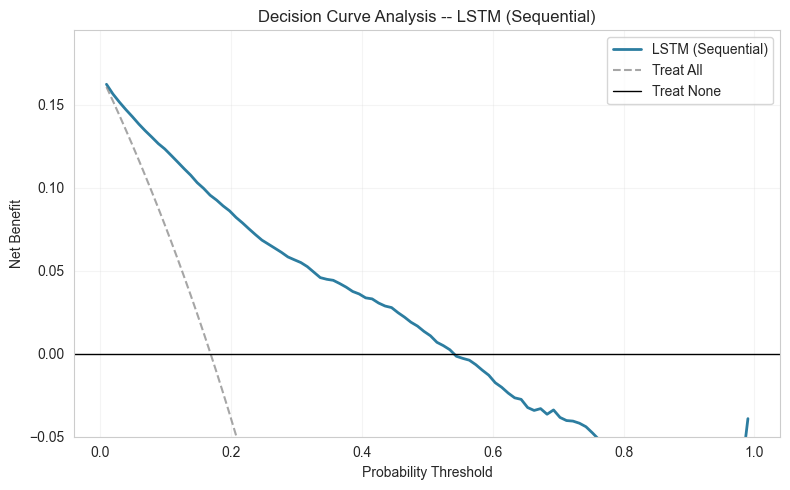

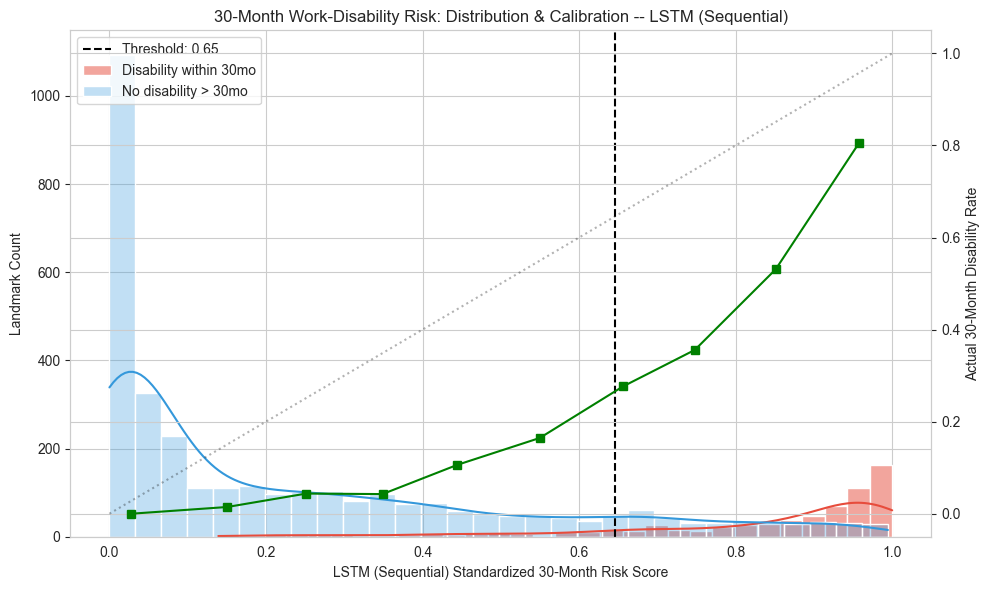

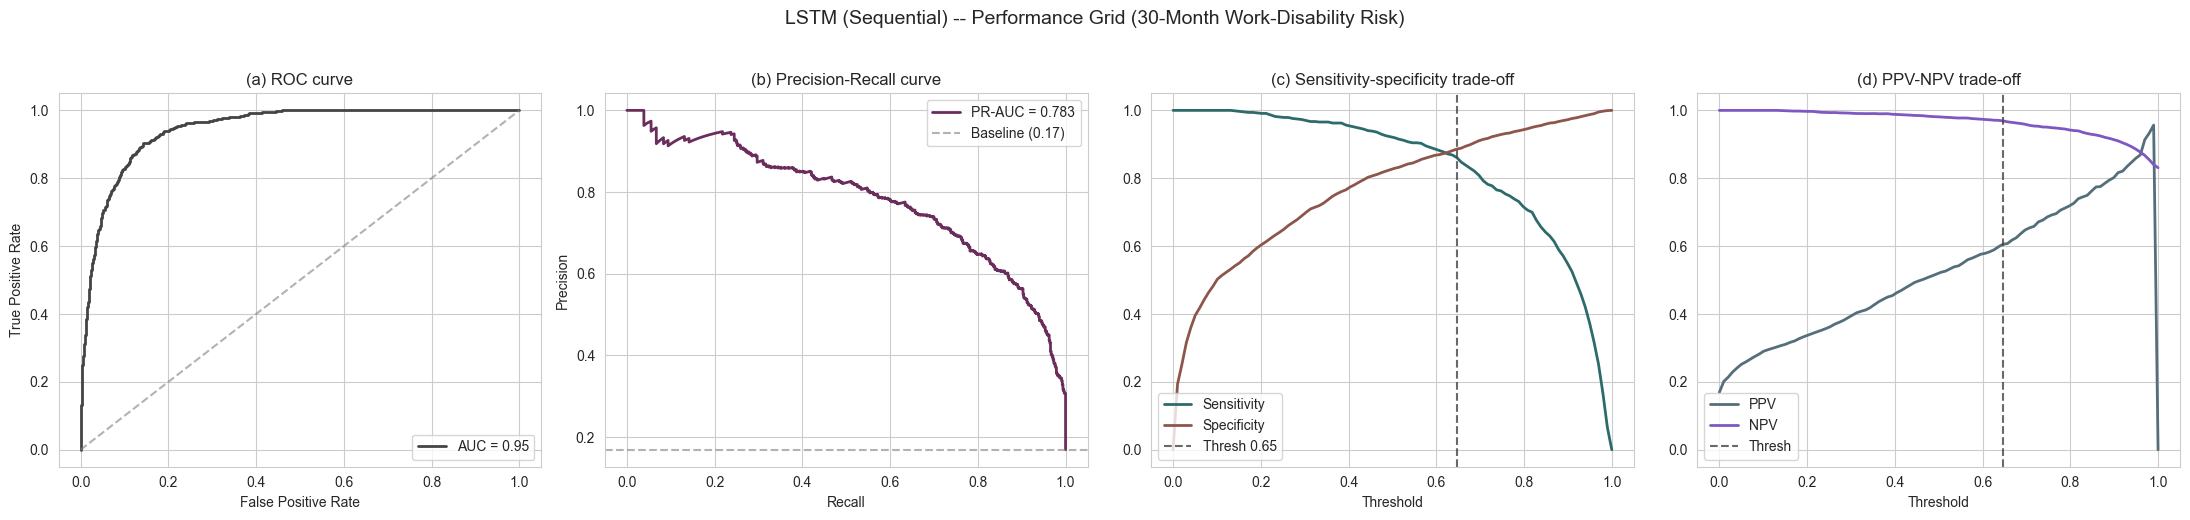

Calculating Permutation Feature Importance...


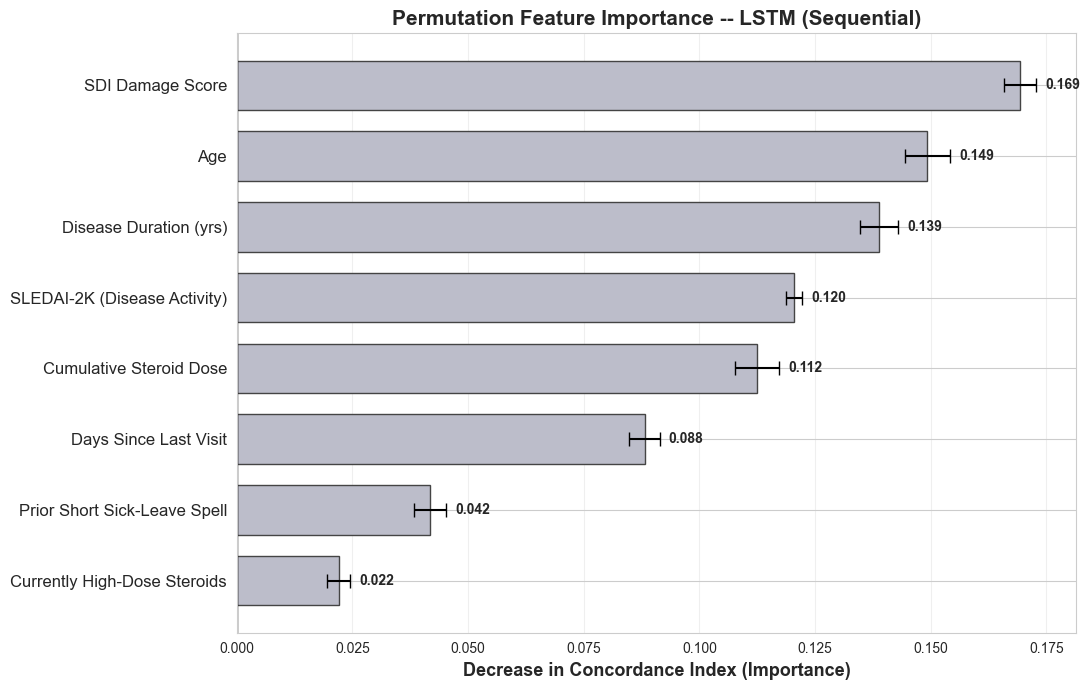

In [7]:
lstm_pipeline = SequentialSurvivalRNN(cell='lstm', horizon_days=HORIZON_DAYS)
res_lstm = lstm_pipeline.run_analysis(land, X_seq, epochs=25)

## Cross-Model Calibration Comparison

FileNotFoundError: [Errno 2] No such file or directory: 'figs/calibration_comparison.pdf'

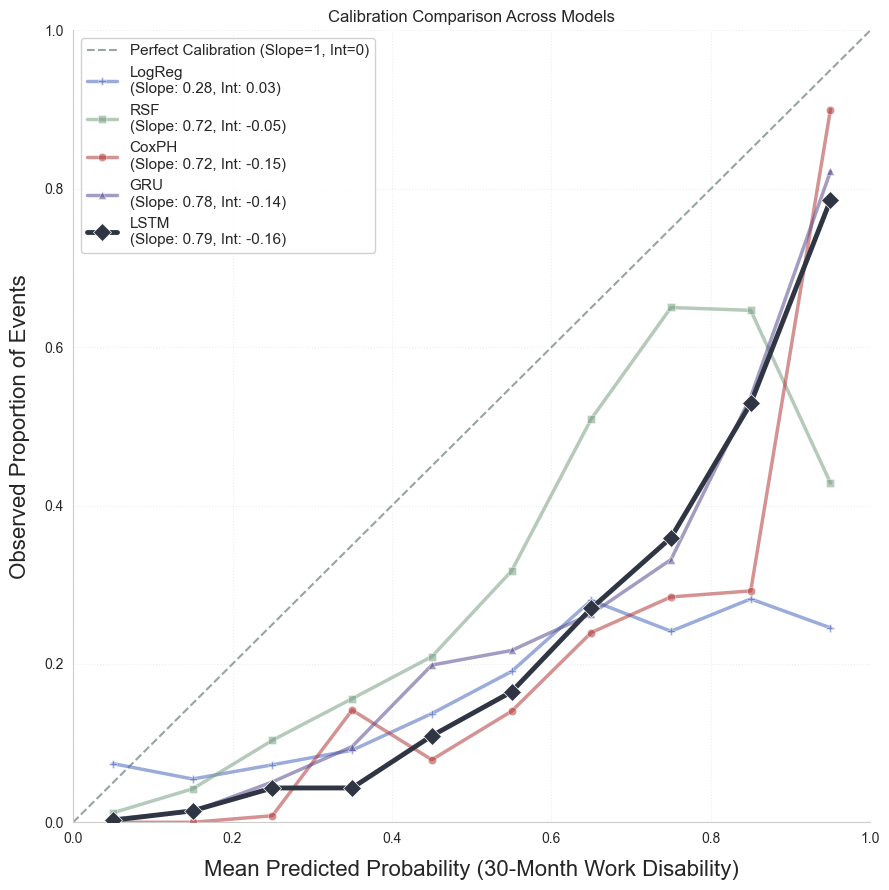

In [8]:
"""Cross-model calibration comparison plot (mirrors the notebook's 'Plots'
cell), built here from each model's *actual* calibration-curve output on
the SLE landmark data rather than the original notebook's hard-coded demo
numbers."""
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.calibration import calibration_curve


def plot_calibration_comparison(results, save="figs/calibration_comparison.pdf"):
    """results: dict of {model_name: (y_true, risks)}"""
    bin_centers = np.linspace(0.05, 0.95, 10)

    plt.figure(figsize=(9, 9), facecolor="white")
    plt.plot([0, 1], [0, 1], linestyle="--", color="#7f8c8d",
              label="Perfect Calibration (Slope=1, Int=0)", alpha=0.8, lw=1.5)

    colors = ["#4a69bd", "#78a083", "#b33939", "#574b90", "#2f3542"]
    markers = ["P", "s", "o", "^", "D"]
    highlight = max(results, key=lambda k: results[k][2])  # highest c-index gets highlighted

    for (model_name, (y_true, risks, _)), color, marker in zip(results.items(), colors, markers):
        prob_true, prob_pred = calibration_curve(y_true, risks, n_bins=10)
        # align onto common bin centers via interpolation for a clean comparison line
        observed = np.interp(bin_centers, prob_pred, prob_true)
        slope, intercept, _, _, _ = stats.linregress(bin_centers, observed)
        label_text = f"{model_name}\n(Slope: {slope:.2f}, Int: {intercept:.2f})"

        is_highlight = model_name == highlight
        plt.plot(bin_centers, observed, marker=marker, label=label_text, color=color,
                  lw=3.5 if is_highlight else 2.5, markersize=9 if is_highlight else 6,
                  alpha=1.0 if is_highlight else 0.55,
                  zorder=10 if is_highlight else 5, markeredgecolor="white", markeredgewidth=0.5)

    plt.xlabel("Mean Predicted Probability (30-Month Work Disability)", fontsize=16, labelpad=10)
    plt.ylabel("Observed Proportion of Events", fontsize=16, labelpad=10)
    plt.legend(loc="upper left", fontsize=11, frameon=True, facecolor="white", framealpha=0.9)
    plt.grid(True, linestyle=":", alpha=0.4, color="#ced4da")
    plt.xlim([0, 1]); plt.ylim([0, 1])
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.title("Calibration Comparison Across Models")
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

all_results = {
    'LogReg': (res_logreg['y'], res_logreg['risks'], res_logreg['c_index']),
    'RSF': (res_rsf['y'], res_rsf['risks'], res_rsf['c_index']),
    'CoxPH': (res_cox['y'], res_cox['risks'], res_cox['c_index']),
    'GRU': (res_gru['y'], res_gru['risks'], res_gru['c_index']),
    'LSTM': (res_lstm['y'], res_lstm['risks'], res_lstm['c_index']),
}
plot_calibration_comparison(all_results)

## SHAP Dashboard

The original notebook's SHAP cell imports an external `grumodelwdashboard.py`
module that was not included in the uploaded files, so it could not be run
verbatim. This reproduces its intent directly against the best-discriminating
sequential model using the `shap` package: SHAP attribution is computed for
each landmark's most recent ("current-visit") feature vector, tiled across
the model's fixed 12-visit input window.


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Best model by C-index: LSTM (0.8026)
Computing SHAP values (KernelExplainer over the last-visit state)...


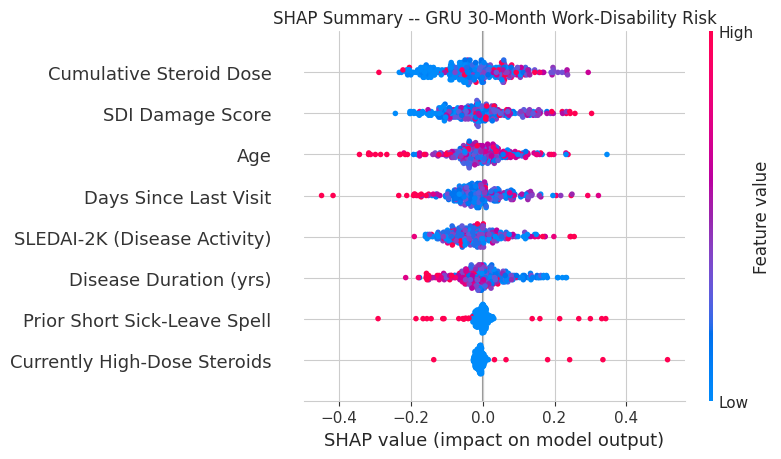

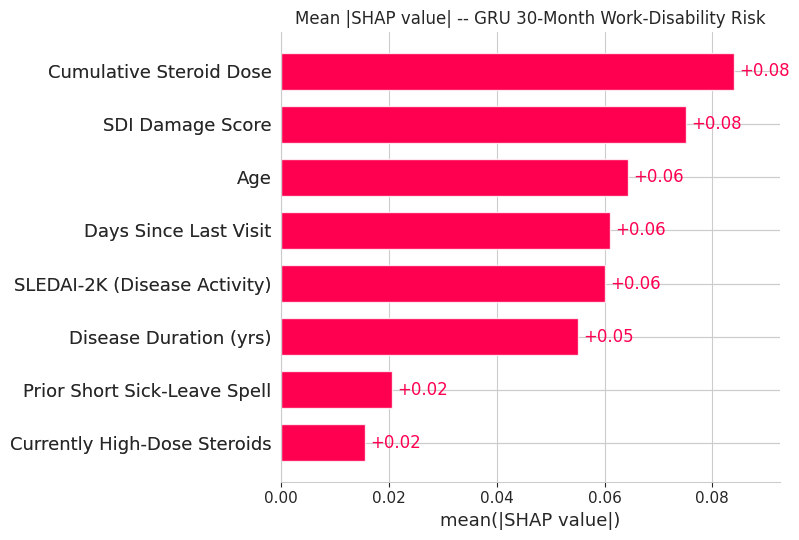

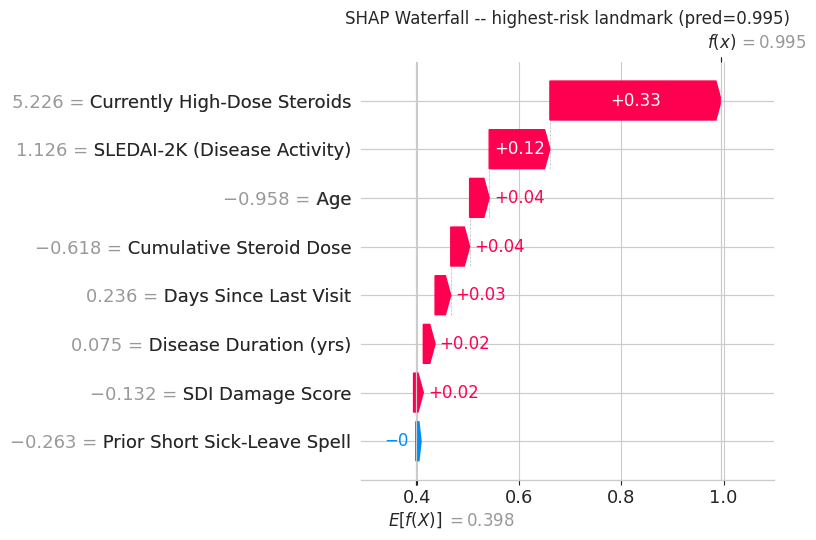

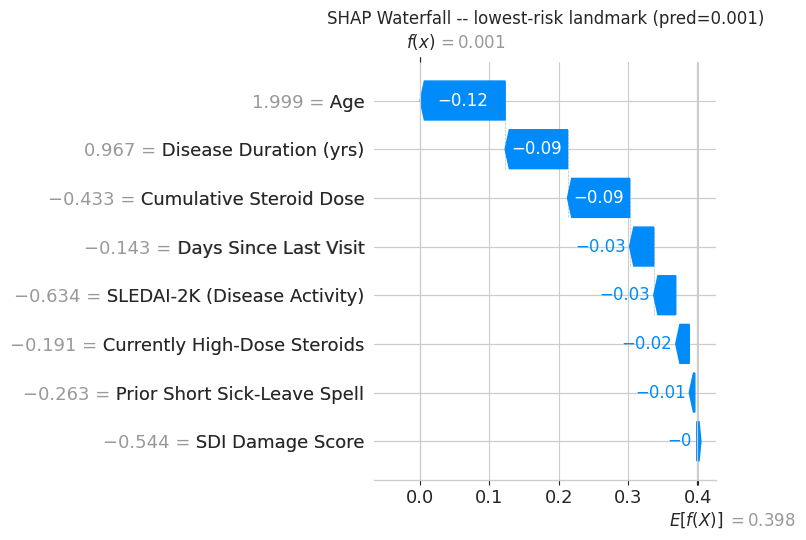


SHAP FEATURE IMPORTANCE (mean |SHAP| over sampled landmarks)
-------------------------------------------------------
                     Feature  Mean |SHAP|
     Cumulative Steroid Dose     0.083958
            SDI Damage Score     0.075152
                         Age     0.064279
       Days Since Last Visit     0.061044
SLEDAI-2K (Disease Activity)     0.059995
      Disease Duration (yrs)     0.054982
Prior Short Sick-Leave Spell     0.020478
Currently High-Dose Steroids     0.015490


In [9]:
"""SHAP explainability dashboard for the trained GRU sequential model.

The original notebook's SHAP/dashboard cell imports a separate, not-supplied
module (`grumodelwdashboard.py`) that is not part of this upload, so it
cannot be executed verbatim. This module reproduces its intent -- a SHAP
explanation layer on top of the best-performing sequential model -- using
the `shap` package directly against the trained GRU classifier from
model_sequential.py.

Because the classifier consumes a (patients, 12-visit, 8-feature) tensor,
SHAP attribution is computed for the "current visit" (the most recent,
last-timestep) feature vector: a background/foreground wrapper tiles each
candidate current-visit vector across the model's fixed sequence length so
that the model sees a constant short-term trajectory ending at that visit.
This is the standard simplification used to make a recurrent risk model
locally explainable at the point of a single clinical visit.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import torch



def run_shap_dashboard(pipeline, land, X_seq, n_background=100, n_explain=300, seed=240):
    rng = np.random.RandomState(seed)
    model = pipeline.model
    model.eval()
    seq_len = pipeline.sequence_length
    feature_names = [DISPLAY_NAMES.get(c, c) for c in pipeline.feature_cols]

    # Last-visit (current-state) feature vectors, in the *model's* scaled
    # space, for every landmark row.
    last_visit = X_seq[:, -1, :]  # already imputed+scaled inside prepare_data
    # Recompute scaled/imputed last-visit features the same way prepare_data does.
    X_full, y_true, weight = pipeline.prepare_data(land, X_seq)
    last_visit_scaled = X_full[:, -1, :]

    def predict_fn(current_visit_batch):
        current_visit_batch = np.asarray(current_visit_batch, dtype=np.float32)
        n = current_visit_batch.shape[0]
        seq = np.repeat(current_visit_batch[:, None, :], seq_len, axis=1)
        with torch.no_grad():
            out = model(torch.FloatTensor(seq)).numpy()
        return out[:, -1, 0]

    bg_idx = rng.choice(len(last_visit_scaled), size=min(n_background, len(last_visit_scaled)),
                         replace=False)
    background = last_visit_scaled[bg_idx]

    ex_idx = rng.choice(len(last_visit_scaled), size=min(n_explain, len(last_visit_scaled)),
                         replace=False)
    explain_set = last_visit_scaled[ex_idx]

    print("Computing SHAP values (KernelExplainer over the last-visit state)...")
    masker = shap.maskers.Independent(background, max_samples=len(background))
    explainer = shap.Explainer(predict_fn, masker, feature_names=feature_names)
    shap_values = explainer(explain_set)

    # --- Summary (beeswarm) plot ---
    plt.figure()
    shap.plots.beeswarm(shap_values, show=False, max_display=len(feature_names))
    plt.title("SHAP Summary -- GRU 30-Month Work-Disability Risk")
    plt.tight_layout()
    plt.savefig("figs/shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # --- Mean |SHAP| bar plot ---
    plt.figure()
    shap.plots.bar(shap_values, show=False, max_display=len(feature_names))
    plt.title("Mean |SHAP value| -- GRU 30-Month Work-Disability Risk")
    plt.tight_layout()
    plt.savefig("figs/shap_bar.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # --- Individual waterfall plots for a high-risk and a low-risk patient ---
    preds = predict_fn(explain_set)
    hi = int(np.argmax(preds))
    lo = int(np.argmin(preds))
    for label, idx in [("highest-risk", hi), ("lowest-risk", lo)]:
        plt.figure()
        shap.plots.waterfall(shap_values[idx], show=False)
        plt.title(f"SHAP Waterfall -- {label} landmark (pred={preds[idx]:.3f})")
        plt.tight_layout()
        plt.savefig(f"figs/shap_waterfall_{label.replace('-', '_')}.png", dpi=150,
                     bbox_inches="tight")
        plt.show()
        plt.close()

    mean_abs = np.abs(shap_values.values).mean(axis=0)
    imp_df = pd.DataFrame({"Feature": feature_names, "Mean |SHAP|": mean_abs}) \
        .sort_values("Mean |SHAP|", ascending=False)
    print("\n" + "=" * 55)
    print("SHAP FEATURE IMPORTANCE (mean |SHAP| over sampled landmarks)")
    print("-" * 55)
    print(imp_df.to_string(index=False))
    print("=" * 55)

    return shap_values, imp_df

best_name = max(all_results, key=lambda k: all_results[k][2])
print(f'Best model by C-index: {best_name} ({all_results[best_name][2]:.4f})')
shap_pipeline = lstm_pipeline if best_name == 'LSTM' else gru_pipeline
shap_values, shap_imp = run_shap_dashboard(shap_pipeline, land, X_seq,
                                            n_background=100, n_explain=300)

## Summary — All Models

In [10]:
summary = pd.DataFrame({
    "Model": list(all_results.keys()),
    "C-index": [v[2] for v in all_results.values()],
}).sort_values("C-index", ascending=False)
print(summary.to_string(index=False))
summary

 Model  C-index
  LSTM 0.802552
   GRU 0.798567
   RSF 0.748343
LogReg 0.608736
 CoxPH 0.604707


,Model,C-index
4,LSTM,0.802552
3,GRU,0.798567
1,RSF,0.748343
0,LogReg,0.608736
2,CoxPH,0.604707
